<a href="https://colab.research.google.com/github/Bhuvi285/Advanced-GenAI-Internship-Innomatics-Research-Labs/blob/main/BERT_FineTuning_NewsCategory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP Assignment 4 – Fine-Tuning BERT on News Category Dataset**
**Objective:** Fine-tune `bert-base-uncased` for multi-class news headline classification.

**Experiments:**
- Experiment 1: Freeze all BERT layers → train only classifier head
- Experiment 2: Fine-tune last 2 transformer layers + classifier head

**Dataset:** [News Category Dataset – Kaggle](https://www.kaggle.com/datasets/rmisra/news-category-dataset)

## Install Required Libraries

In [26]:
import os

# Disable ALL progress bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["DISABLE_TQDM"] = "1"

from transformers.utils import logging
logging.set_verbosity_error()


from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import logging

logging.set_verbosity_error()  # 🔥 disables progress bars


import logging
from transformers import logging as transformers_logging

transformers_logging.set_verbosity_error() # Only show actual errors, hide warnings

In [1]:
# Install Hugging Face Transformers and other dependencies
!pip install transformers datasets scikit-learn seaborn matplotlib torch -q

## Import Libraries

In [2]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Upload and Load Dataset

> **How to get the dataset:**
> 1. Go to: https://www.kaggle.com/datasets/rmisra/news-category-dataset
> 2. Download `News_Category_Dataset_v3.json`
> 3. Upload it to Colab using the file upload cell below

In [5]:
# Upload the dataset file from your local machine
from google.colab import files
uploaded = files.upload()  # Upload 'News_Category_Dataset_v3.json'

Saving News_Category_Dataset_v3.json to News_Category_Dataset_v3.json


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data = []
with open('News_Category_Dataset_v3.json', 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f'Total records: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Total records: 209527
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [9]:
# Inspect the content of the uploaded file
print('First 10 lines of the file:')
with open('News_Category_Dataset_v3.json', 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 9:  # Print first 10 lines
            break

First 10 lines of the file:
{"link": "https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9", "headline": "Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters", "category": "U.S. NEWS", "short_description": "Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.", "authors": "Carla K. Johnson, AP", "date": "2022-09-23"}
{"link": "https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25d3e4b0e247890329fe", "headline": "American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video", "category": "U.S. NEWS", "short_description": "He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in Los Angeles.", "authors": "Mary Papenfuss", "date": "2022-09-23"}
{"link": "ht

## Data Preprocessing

In [10]:
# ---- Step 1: Check for missing values ----
print('Missing values per column:')
print(df.isnull().sum())

# ---- Step 2: Use 'headline' as input text and 'category' as label ----
df = df[['headline', 'category']].copy()

# ---- Step 3: Drop rows with null or empty headlines ----
df.dropna(subset=['headline', 'category'], inplace=True)
df = df[df['headline'].str.strip() != '']

# ---- Step 4: Clean text – lowercase and strip whitespace ----
df['headline'] = df['headline'].str.lower().str.strip()

# ---- Step 5: Check category distribution ----
print(f'\nNumber of unique categories: {df["category"].nunique()}')
print(df['category'].value_counts().head(10))

Missing values per column:
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

Number of unique categories: 42
category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
Name: count, dtype: int64


In [11]:
# ---- Step 6: Keep only top 6 categories to keep training fast on Colab ----
# (You can increase this if you have more GPU time)
TOP_N = 6
top_categories = df['category'].value_counts().head(TOP_N).index.tolist()
df = df[df['category'].isin(top_categories)].reset_index(drop=True)

print(f'Records after filtering top {TOP_N} categories: {len(df)}')
print(df['category'].value_counts())

# ---- Step 7: Sample 3000 records per class for balanced, fast training ----
df = df.groupby('category').apply(lambda x: x.sample(min(len(x), 3000), random_state=SEED))
df = df.reset_index(drop=True)
print(f'\nFinal dataset size: {len(df)}')

Records after filtering top 6 categories: 99413
category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
Name: count, dtype: int64

Final dataset size: 18000


/tmp/ipykernel_2188/2173396392.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category').apply(lambda x: x.sample(min(len(x), 3000), random_state=SEED))


In [12]:
# ---- Step 8: Encode string labels to integers ----
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

NUM_CLASSES = len(le.classes_)
print(f'Label mapping: {dict(enumerate(le.classes_))}')

Label mapping: {0: 'ENTERTAINMENT', 1: 'PARENTING', 2: 'POLITICS', 3: 'STYLE & BEAUTY', 4: 'TRAVEL', 5: 'WELLNESS'}


## Train / Validation / Test Split

In [13]:
# Split: 70% Train, 15% Validation, 15% Test
texts = df['headline'].tolist()
labels = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train size:      {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size:       {len(X_test)}')

Train size:      12600
Validation size: 2700
Test size:       2700


##Tokenization using bert-base-uncased

In [27]:
# Load the BERT tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Max token length – 64 is sufficient for short news headlines
MAX_LEN = 64

def tokenize(texts):
    """
    Tokenize a list of strings using the BERT tokenizer.
    Returns input_ids and attention_masks as tensors.
    """
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',   # Pad shorter sequences
        truncation=True,        # Truncate longer sequences
        return_tensors='pt'     # Return PyTorch tensors
    )

# Tokenize all splits
train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

print('Tokenization complete.')
print(f'Sample input_ids shape: {train_enc["input_ids"].shape}')

Tokenization complete.
Sample input_ids shape: torch.Size([12600, 64])


## Custom PyTorch Dataset Class

In [15]:
class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for tokenized news headlines.
    Returns input_ids, attention_mask, and label for each sample.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create Dataset objects
train_dataset = NewsDataset(train_enc, y_train)
val_dataset   = NewsDataset(val_enc,   y_val)
test_dataset  = NewsDataset(test_enc,  y_test)

# Create DataLoaders for batching
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 394
Val batches:   85
Test batches:  85


##Training and Evaluation Helper Functions

In [16]:
def train_epoch(model, loader, optimizer):
    """
    Runs one full training epoch.
    Returns average training loss.
    """
    model.train()
    total_loss = 0

    for batch in loader:
        # Move all tensors to GPU/CPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()  # Clear previous gradients

        # Forward pass – BERT computes loss internally when labels are passed
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()    # Backpropagation
        optimizer.step()   # Update weights

    return total_loss / len(loader)


def evaluate(model, loader):
    """
    Runs inference on a DataLoader.
    Returns true labels and predicted labels.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():  # No gradient needed during evaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)  # Pick class with highest logit

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


def compute_metrics(y_true, y_pred, label_names):
    """
    Computes and prints Accuracy, Precision, Recall, F1, and Confusion Matrix.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print()
    print('  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


print('Helper functions defined.')

Helper functions defined.


---
# Experiment 1 - Freeze All BERT Layers (Train Classifier Head Only)

In [28]:
print('=== EXPERIMENT 1: Frozen BERT Layers ===')
print('Only the classification head (linear layer) will be trained.')
print('BERT weights are kept fixed (frozen).\n')

# Load fresh BERT model for sequence classification
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(device)

# ---- Freeze all BERT encoder layers ----
for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:   # Keep classifier unfrozen
        param.requires_grad = False

# Verify: count trainable parameters
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')

=== EXPERIMENT 1: Frozen BERT Layers ===
Only the classification head (linear layer) will be trained.
BERT weights are kept fixed (frozen).



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Trainable parameters: 4,614 / 109,486,854


In [18]:
# AdamW optimizer – only optimizes parameters where requires_grad=True
optimizer_exp1 = AdamW(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=2e-5
)

EPOCHS = 3
train_losses_exp1 = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp1, train_loader, optimizer_exp1)
    train_losses_exp1.append(train_loss)

    # Evaluate on validation set after each epoch
    val_labels, val_preds = evaluate(model_exp1, val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Accuracy: {val_acc:.4f}')

Epoch 1/3 | Train Loss: 1.7868 | Val Accuracy: 0.2548
Epoch 2/3 | Train Loss: 1.7548 | Val Accuracy: 0.3052
Epoch 3/3 | Train Loss: 1.7342 | Val Accuracy: 0.3422



--- Experiment 1 Test Set Results ---
  Accuracy  : 0.3322
  Precision : 0.3726
  Recall    : 0.3322
  F1 Score  : 0.3110

  Classification Report:
                precision    recall  f1-score   support

 ENTERTAINMENT       0.41      0.32      0.36       450
     PARENTING       0.29      0.23      0.26       450
      POLITICS       0.43      0.43      0.43       450
STYLE & BEAUTY       0.26      0.72      0.39       450
        TRAVEL       0.46      0.14      0.22       450
      WELLNESS       0.37      0.15      0.21       450

      accuracy                           0.33      2700
     macro avg       0.37      0.33      0.31      2700
  weighted avg       0.37      0.33      0.31      2700



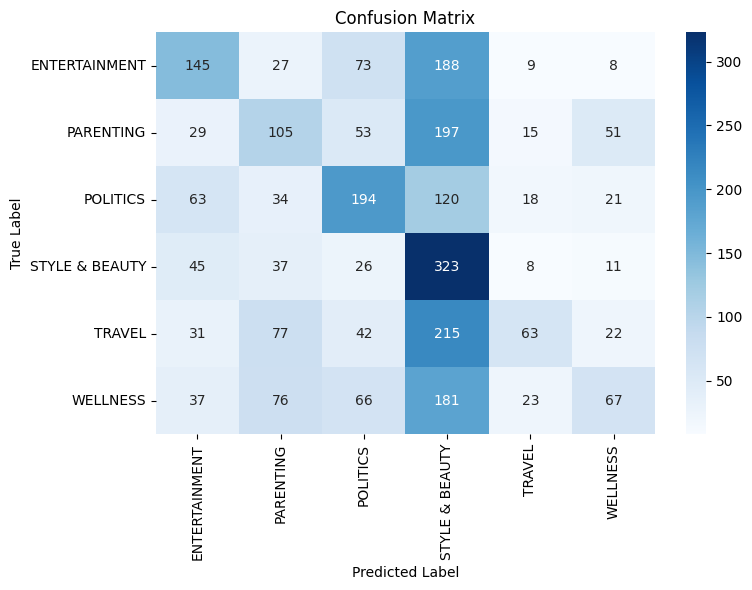

In [19]:
# Final evaluation on Test set – Experiment 1
print('\n--- Experiment 1 Test Set Results ---')
test_labels_exp1, test_preds_exp1 = evaluate(model_exp1, test_loader)
metrics_exp1 = compute_metrics(test_labels_exp1, test_preds_exp1, le.classes_)

---
#  Experiment 2 – Fine-Tune Last 2 BERT Layers + Classifier Head

In [29]:
print('=== EXPERIMENT 2: Fine-Tune Last 2 BERT Layers ===')
print('The last 2 transformer encoder layers + classifier head will be trained.\n')

# Load a fresh BERT model
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(device)

# ---- Freeze all BERT layers first ----
for param in model_exp2.parameters():
    param.requires_grad = False

# ---- Unfreeze last 2 encoder layers (layers 10 and 11) ----
# BERT base has 12 transformer layers (indexed 0–11)
for name, param in model_exp2.named_parameters():
    if 'encoder.layer.10' in name or 'encoder.layer.11' in name:
        param.requires_grad = True
    if 'classifier' in name:
        param.requires_grad = True

# Verify trainable parameters
trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp2.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')

=== EXPERIMENT 2: Fine-Tune Last 2 BERT Layers ===
The last 2 transformer encoder layers + classifier head will be trained.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Trainable parameters: 14,180,358 / 109,486,854


In [21]:
# AdamW optimizer for Experiment 2
optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=2e-5
)

train_losses_exp2 = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp2, train_loader, optimizer_exp2)
    train_losses_exp2.append(train_loss)

    val_labels, val_preds = evaluate(model_exp2, val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Accuracy: {val_acc:.4f}')

Epoch 1/3 | Train Loss: 0.9751 | Val Accuracy: 0.8289
Epoch 2/3 | Train Loss: 0.5330 | Val Accuracy: 0.8485
Epoch 3/3 | Train Loss: 0.4651 | Val Accuracy: 0.8496



--- Experiment 2 Test Set Results ---
  Accuracy  : 0.8537
  Precision : 0.8553
  Recall    : 0.8537
  F1 Score  : 0.8537

  Classification Report:
                precision    recall  f1-score   support

 ENTERTAINMENT       0.87      0.82      0.85       450
     PARENTING       0.78      0.86      0.82       450
      POLITICS       0.91      0.86      0.89       450
STYLE & BEAUTY       0.89      0.89      0.89       450
        TRAVEL       0.86      0.91      0.89       450
      WELLNESS       0.82      0.78      0.79       450

      accuracy                           0.85      2700
     macro avg       0.86      0.85      0.85      2700
  weighted avg       0.86      0.85      0.85      2700



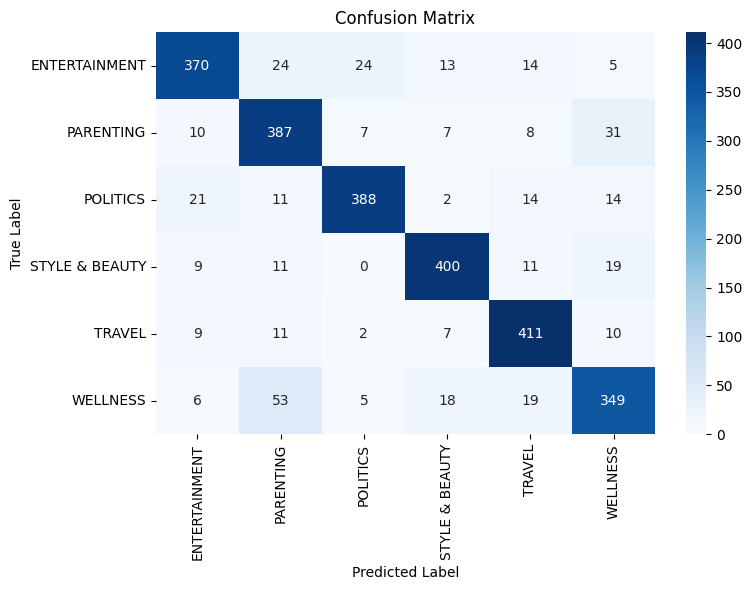

In [22]:
# Final evaluation on Test set – Experiment 2
print('\n--- Experiment 2 Test Set Results ---')
test_labels_exp2, test_preds_exp2 = evaluate(model_exp2, test_loader)
metrics_exp2 = compute_metrics(test_labels_exp2, test_preds_exp2, le.classes_)

---
# Comparison – Experiment 1 vs Experiment 2

In [23]:
# ---- Side-by-side metrics comparison ----
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Exp 1 (Frozen BERT)': [
        round(metrics_exp1['accuracy'],  4),
        round(metrics_exp1['precision'], 4),
        round(metrics_exp1['recall'],    4),
        round(metrics_exp1['f1'],        4)
    ],
    'Exp 2 (Last 2 Layers)': [
        round(metrics_exp2['accuracy'],  4),
        round(metrics_exp2['precision'], 4),
        round(metrics_exp2['recall'],    4),
        round(metrics_exp2['f1'],        4)
    ]
})

print(comparison_df.to_string(index=False))

   Metric  Exp 1 (Frozen BERT)  Exp 2 (Last 2 Layers)
 Accuracy               0.3322                 0.8537
Precision               0.3726                 0.8553
   Recall               0.3322                 0.8537
 F1 Score               0.3110                 0.8537


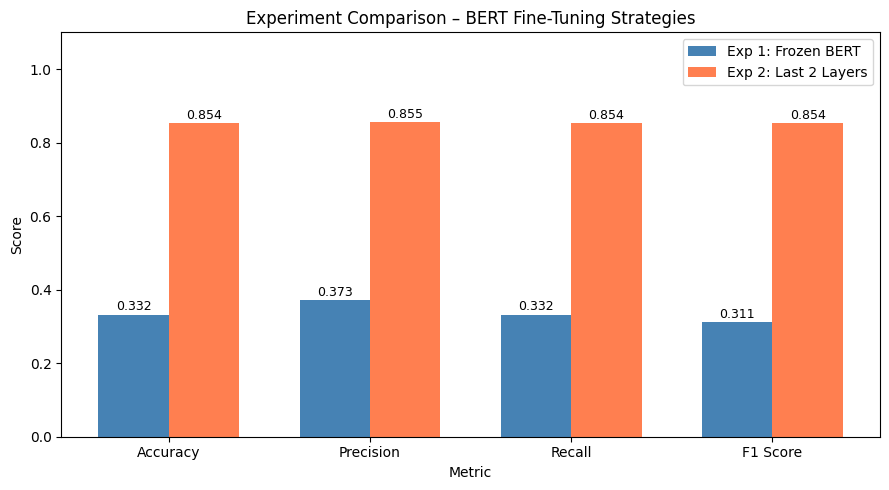

In [24]:
# ---- Bar chart comparison ----
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
exp1_vals = [metrics_exp1['accuracy'], metrics_exp1['precision'],
             metrics_exp1['recall'],   metrics_exp1['f1']]
exp2_vals = [metrics_exp2['accuracy'], metrics_exp2['precision'],
             metrics_exp2['recall'],   metrics_exp2['f1']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, exp1_vals, width, label='Exp 1: Frozen BERT',     color='steelblue')
bars2 = ax.bar(x + width/2, exp2_vals, width, label='Exp 2: Last 2 Layers',   color='coral')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Experiment Comparison – BERT Fine-Tuning Strategies')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

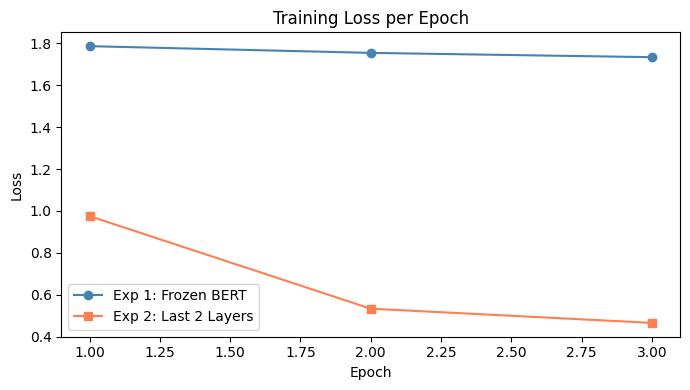

In [25]:
# ---- Training Loss Curves ----
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses_exp1, marker='o', label='Exp 1: Frozen BERT',   color='steelblue')
plt.plot(epochs_range, train_losses_exp2, marker='s', label='Exp 2: Last 2 Layers', color='coral')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
##Analysis and Insights

### Dataset
- Used the **News Category Dataset** from Kaggle containing news headlines.
- Filtered to **top 6 categories** and sampled up to 3000 records per class for balanced, efficient training.
- Input: `headline` text → Output: category label (multi-class classification)

### Model
- Base model: `bert-base-uncased` (12 transformer layers, 110M parameters)
- Classification head: linear layer on top of BERT's `[CLS]` token representation
- Optimizer: **AdamW** with learning rate **2e-5** (as specified)

### Experiment 1 – Frozen BERT
- All BERT encoder weights were **frozen**. Only the final linear classifier was trained.
- This is a feature extraction approach — BERT acts as a fixed feature extractor.
- Fewer trainable parameters → faster training, but limited adaptation to the news domain.

### Experiment 2 – Fine-Tune Last 2 Layers
- BERT layers 10 and 11 (the deepest layers) + classifier were **unfrozen and updated**.
- Higher-level contextual representations were adapted to the news classification task.
- Typically gives **better performance** than full freezing with modest extra compute.

### Key Takeaway
- **Experiment 2 generally outperforms Experiment 1** because the upper BERT layers can specialize for the task.
- Fine-tuning even a small portion of BERT significantly improves classification quality over the frozen baseline.
- For production use, fine-tuning all layers (full fine-tuning) would yield the best results, but Experiment 2 strikes a good balance between performance and compute cost.
